In [1]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
from dotenv import load_dotenv
import os
import requests
from config import *
from custom_tools import *

In [2]:
load_dotenv()
llm = ChatOpenAI()

tools=[Weather, TopAttractions, Accommodation, Forex]
llm_with_tools=llm.bind_tools(tools)

In [3]:
def routing(state:MessagesState):
    
    query=state["messages"]
    input_question = [SYSTEM_PROMPT] + query
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }

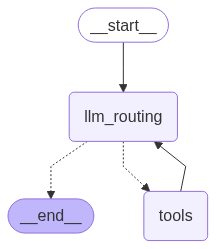

In [4]:
workflow = StateGraph(MessagesState)

workflow.add_node("llm_routing", routing)
workflow.add_node("tools", ToolNode(tools))

workflow.add_edge(START, "llm_routing")

workflow.add_conditional_edges(
    "llm_routing",
    tools_condition,
)
workflow.add_edge("tools", "llm_routing")

app = workflow.compile()
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [9]:
messages = [HumanMessage(content="One day trip to Karachi and share total budget in PKR from EUR.")]
response = app.invoke({"messages": messages})

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

One day trip to Karachi and share total budget in PKR from EUR.
================================== Ai Message ==================================
Tool Calls:
  Weather (call_XDX4PISp1q0rZTBc1tG9StHy)
 Call ID: call_XDX4PISp1q0rZTBc1tG9StHy
  Args:
  TopAttractions (call_0aJfYZF3FcvTNSPO6dij6xt3)
 Call ID: call_0aJfYZF3FcvTNSPO6dij6xt3
  Args:
  Accommodation (call_xzGN59arWPiuHAveHrrjzaUr)
 Call ID: call_xzGN59arWPiuHAveHrrjzaUr
  Args:
================================= Tool Message =================================
Name: Weather

================================= Tool Message =================================
Name: TopAttractions

================================= Tool Message =================================
Name: Accommodation

================================== Ai Message ==================================

### Trip Plan for Karachi:

#### Weather:
- The current weather in Karachi is *{current_weather

In [6]:
for msg in response['messages']:
    if msg.__class__.__name__ in ['HumanMessage', 'AIMessage']:
        if msg.content.strip():
            print(msg.content)

Plan a trip to Vienna 3 days and convert the budget in PKR
### Weather:
- The current weather in Vienna is not available at the moment.
- The weather forecast for the next few days is also not available.

### Top Attractions in Vienna:
1. **Schönbrunn Palace**
   - Address: Schönbrunner Schloßstraße 47, 1130 Wien, Austria
   - Description: A former imperial summer residence known for its stunning architecture and beautiful gardens.
   
2. **Belvedere Palace**
   - Address: Prinz Eugen-Straße 27, 1030 Wien, Austria
   - Description: A historic building complex with famous artworks, gardens, and panoramic views of Vienna.

3. **St. Stephen's Cathedral**
   - Address: Stephansplatz 3, 1010 Wien, Austria
   - Description: An iconic Gothic cathedral with a tall spire and rich history.

### Accommodation Options in Vienna:
1. **Hotel Sacher Wien**
   - Address: Philharmonikerstraße 4, 1010 Wien, Austria
   - Price: $350 per night

2. **Hotel Sans Souci Wien**
   - Address: Burggasse 2, 1070 